# **Liberías**

In [1]:
pip install mplsoccer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.4/86.4 kB 3.0 MB/s eta 0:00:00


In [2]:
#from mplsoccer import PyPizza
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re

from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor

from sqlalchemy import create_engine, select
from sqlalchemy import text
from sqlalchemy.orm import sessionmaker

import glob
import os

pd.set_option('display.max_rows',30)
pd.set_option('display.max_columns',None)

In [3]:
#df = pd.read_excel('/content/drive/MyDrive/MIS_ANÁLISIS/Datos/datos_wyscout/MLPFD/Salida/s_Scout_TempActual_Jugadores.xlsx')
#df = pd.read_excel('/content/drive/MyDrive/MIS_ANÁLISIS/Datos/datos_wyscout/MLPFD/Salida/s_Scout_Historico_Jugadores.xlsx')

In [4]:
#df_players = df.copy()
#hacer copia para no perder el original
#df_players = df.drop('Unnamed: 0', axis=1)
#df_players = df_players.drop_duplicates()

# **Lectura BBDD**

In [5]:
# Configuración de la conexión a PostgreSQL
usuario = "avnadmin"
contrasena = "AVNS_Snql1CSp1zYrJCH6cXE"
servidor = "my-database-pg-my-data22.f.aivencloud.com"
puerto = "13676"
base_datos = "my_wyscout"

# Crea la cadena de conexión
conexion_str = f'postgresql+psycopg2://{usuario}:{contrasena}@{servidor}:{puerto}/{base_datos}'
engine = create_engine(conexion_str)

In [6]:
s_sql = text("""SELECT "Competición", "Temporada", "Posición Principal",	"Jugador", "Equipo", "Equipo durante el período seleccionado", "Posición específica",
	"Edad", "Valor de mercado", "Vencimiento contrato", "Partidos jugados", "Minutos jugados", "Goles", "xG", "Asistencias", "xA", "Duelos/90",
	"Duelos ganados %", "País de nacimiento", "Pasaporte", "Pie", "Altura", "Peso", "En préstamo", "Acciones defensivas realizadas/90", "Duelos defensivos/90", "Duelos defensivos ganados %",
	"Duelos aéreos/90", "Duelos aéreos ganados %", "Entradas/90", "Acciones de ataque exitosas/90", "Asistencias/90", "Asistencias/90.1",
    "Ataque en profundidad/90", "Carreras en progresión/90", "Centros desde el último tercio/90", "Centros desde la banda derecha/90",
    "Centros/90",
	"Desmarques/90", "Duelos aéreos/90.1", "Duelos atacantes ganados %", "Duelos atacantes/90", "Faltas recibidas/90", "Faltas/90",
	"Goles (excepto los penaltis)", "Goles de cabeza/90", "Goles evitados", "Goles hechos %", "Goles recibidos/90", "Goles/90",
	 "Interceptaciones/90", "Jugadas claves/90", "Longitud media pases, m",
    "Longitud media pases largos, m", "Pais_Comp", 	"Paradas %", "Pases al área de penalti/90",
    "Pases cortos / medios/90", "Pases en el último tercio/90", "Pases hacia adelante/90", "Pases hacía atrás recibidos del arquero/90",
	"Pases hacía el área pequeña %", "Pases largos recibidos/90", "Pases largos/90", "Pases laterales/90", "Pases progresivos/90",
    "Pases recibidos/90", "Pases/90", "Penaltis a favor", "Penaltis realizados %", "Porterías imbatidas/90",
    "Posesión conquistada después de una interceptación", "Precisión centros %", "Precisión centros desde la banda derecha %",
    "Precisión centros desde la banda izquierda %", "Precisión pases %", "Precisión pases cortos / medios %",
	"Precisión pases en el último tercio %", "Precisión pases en profundidad %", "Precisión pases hacia adelante %",
    "Precision pases hacia atrás %",  "Precisión pases laterales %", "Precisión pases progresivos %", "Regates realizados %", "Regates/90",
    "Remates en contra", "Remates en contra/90", "Remates", "Remates/90",
	"Salidas/90", "Second assists/90", "Tarjetas amarillas", "Tarjetas rojas", "Tarjetas rojas/90", "Third assists/90",
    "Tiros a la portería %", "Tiros interceptados/90", "Tiros libres directos %", "Tiros libres directos/90", "Tiros libres/90",
    "Toques en el área de penalti/90", "xA/90",  "xG en contra", "xG en contra/90", "xG/90",
	"Goles, excepto los penaltis/90", "Posesión conquistada después de una entrada", "Aceleraciones/90", "Centros al área pequeña/90",
    "Centros desde la banda izquierda/90", "Córneres/90",
    "Fecha_Actualizacion",
    "Goles de cabeza", "Goles evitados/90", "Goles recibidos",
	"Pases en profundidad/90", "Pases hacia atrás/90", "Precisión desmarques %",
	"Precisión pases largos %", "Tarjetas amarillas/90"
from jugadores j
union
SELECT "Competición", "Temporada", "Posición Principal",	"Jugador", "Equipo", "Equipo durante el período seleccionado", "Posición específica",
	"Edad", "Valor de mercado", "Vencimiento contrato", "Partidos jugados", "Minutos jugados", "Goles", "xG", "Asistencias", "xA", "Duelos/90",
	"Duelos ganados %", "País de nacimiento", "Pasaporte", "Pie", "Altura", "Peso", "En préstamo", "Acciones defensivas realizadas/90", "Duelos defensivos/90", "Duelos defensivos ganados %",
	"Duelos aéreos/90", "Duelos aéreos ganados %", "Entradas/90", "Acciones de ataque exitosas/90", "Asistencias/90", "Asistencias/90.1",
    "Ataque en profundidad/90", "Carreras en progresión/90", "Centros desde el último tercio/90", "Centros desde la banda derecha/90",
    "Centros/90",
	"Desmarques/90", "Duelos aéreos/90.1", "Duelos atacantes ganados %", "Duelos atacantes/90", "Faltas recibidas/90", "Faltas/90",
	"Goles (excepto los penaltis)", "Goles de cabeza/90", "Goles evitados", "Goles hechos %", "Goles recibidos/90", "Goles/90",
	 "Interceptaciones/90", "Jugadas claves/90", "Longitud media pases, m",
    "Longitud media pases largos, m", "Pais_Comp", 	"Paradas %", "Pases al área de penalti/90",
    "Pases cortos / medios/90", "Pases en el último tercio/90", "Pases hacia adelante/90", "Pases hacía atrás recibidos del arquero/90",
	"Pases hacía el área pequeña %", "Pases largos recibidos/90", "Pases largos/90", "Pases laterales/90", "Pases progresivos/90",
    "Pases recibidos/90", "Pases/90", "Penaltis a favor", "Penaltis realizados %", "Porterías imbatidas/90",
    "Posesión conquistada después de una interceptación", "Precisión centros %", "Precisión centros desde la banda derecha %",
    "Precisión centros desde la banda izquierda %", "Precisión pases %", "Precisión pases cortos / medios %",
	"Precisión pases en el último tercio %", "Precisión pases en profundidad %", "Precisión pases hacia adelante %",
    "Precision pases hacia atrás %",  "Precisión pases laterales %", "Precisión pases progresivos %", "Regates realizados %", "Regates/90",
    "Remates en contra", "Remates en contra/90", "Remates", "Remates/90",
	"Salidas/90", "Second assists/90", "Tarjetas amarillas", "Tarjetas rojas", "Tarjetas rojas/90", "Third assists/90",
    "Tiros a la portería %", "Tiros interceptados/90", "Tiros libres directos %", "Tiros libres directos/90", "Tiros libres/90",
    "Toques en el área de penalti/90", "xA/90",  "xG en contra", "xG en contra/90", "xG/90",
	"Goles, excepto los penaltis/90", "Posesión conquistada después de una entrada", "Aceleraciones/90", "Centros al área pequeña/90",
    "Centros desde la banda izquierda/90", "Córneres/90",
    "Fecha_Actualizacion",
    "Goles de cabeza", "Goles evitados/90", "Goles recibidos",
	"Pases en profundidad/90", "Pases hacia atrás/90", "Precisión desmarques %",
	"Precisión pases largos %", "Tarjetas amarillas/90"
from hist_jugadores hj
;""")

In [7]:
# Ejecutar la consulta SQL
df = pd.read_sql(s_sql, conexion_str)  # Cargar resultados en un DataFrame

In [8]:
df_players = df.copy()
#hacer copia para no perder el original
#df_players = df.drop('Unnamed: 0', axis=1)
df_players = df_players.drop_duplicates()

# **Métricas Wyscout**

In [9]:
fase_defensiva = ['Acciones defensivas realizadas/90','Duelos aéreos/90',
                'Duelos aéreos ganados %','Duelos defensivos ganados %','Duelos defensivos/90','Entradas/90',
                'Faltas/90','Interceptaciones/90','Posesión conquistada después de una entrada',
                'Posesión conquistada después de una interceptación','Tarjetas amarillas','Tarjetas amarillas/90',
                'Tarjetas rojas','Tarjetas rojas/90','Tiros interceptados/90']

abp = ['Córneres/90','Penaltis a favor','Penaltis realizados %','Tiros libres directos %',
       'Tiros libres directos/90','Tiros libres/90']

acc_ofensivas = ['Acciones de ataque exitosas/90','Aceleraciones/90','Asistencias','Asistencias/90',
                'Carreras en progresión/90','Centros al área pequeña/90','Centros desde la banda derecha/90',
                'Centros desde la banda izquierda/90','Centros/90','Duelos atacantes ganados %',
                'Duelos atacantes/90','Faltas recibidas/90','Goles','Goles (excepto los penaltis)',
                'Goles de cabeza','Goles de cabeza/90','Goles hechos %','Goles, excepto los penaltis/90',
                'Goles/90','Pases largos recibidos/90','Pases recibidos /90','Precisión centros %',
                'Precisión centros desde la banda derecha %','Precisión centros desde la banda izquierda %',
                'Regates realizados %','Regates/90','Remates','Remates/90','Tiros a la portería %',
                'Toques en el área de penalti/90','xG','xG/90']

fisica = ['Total Distance per 90','Running Distance per 90 (15-20 km/h)','HSR Distance per 90 (20-25 km/h)',
          'Sprinting Distance per 90 (+25 km/h)','HI Distance per 90 (+20 km/h)','Meter/Min','Max Speed (km/h)',
          'Count Medium Acceleration per 90 (1.5 m/s² to 3 m/s²)','Count High Acceleration per 90 (+3 m/s²)',
          'Count Medium Deceleration per 90 (-1.5 m/s² to -3 m/s²)','Count High Deceleration per 90 (-3 m/s²)',
          'Count HSR per 90 (20-25 km/h)','Count Sprint per 90 (+25 km/h)','Count HI per 90 (+20 km/h)']

jugadas_clave = ['Asistencias','Asistencias/90',
                'Ataque en profundidad/90','Centros desde el último tercio/90','Desmarques/90',
                'Jugadas claves/90','Pases al área de penalti/90','Pases en el último tercio/90',
                'Pases en profundidad/90','Pases hacía el área pequeña %','Pases progresivos/90',
                'Precisión desmarques %','Precisión pases en el último tercio %',
                'Precisión pases en profundidad %','Precisión pases progresivos %','Second assists/90',
                'Third assists/90','xA','xA/90']

organizacion = ['Longitud media pases largos, m','Longitud media pases, m','Pases cortos / medios /90',
                'Pases hacia adelante/90','Pases hacia atrás/90','Pases largos/90','Pases laterales/90',
                'Pases/90','Precisión pases %','Precisión pases cortos / medios %',
                'Precisión pases hacia adelante %','Precision pases hacia atrás %','Precisión pases largos %',
                'Precisión pases laterales %']

portero = ['Acciones defensivas realizadas/90','Duelos aéreos/90',
          'Duelos aéreos ganados %','Duelos defensivos ganados %','Duelos ganados %','Goles evitados',
          'Goles evitados/90','Goles recibidos','Goles recibidos/90','Longitud media pases largos, m',
          'Longitud media pases, m','Paradas %','Pases hacia adelante/90',
          'Pases hacía atrás recibidos del arquero/90','Pases hacia atrás/90','Pases largos/90',
          'Pases laterales/90','Pases/90','Porterías imbatidas en los 90','Precisión pases %',
          'Precisión pases cortos / medios %','Precisión pases hacia adelante %',
          'Precision pases hacia atrás %','Precisión pases largos %','Precisión pases laterales %',
          'Remates en contra','Remates en contra/90','Salidas/90','xG en contra','xG en contra/90']

Finalización = ['Goles', 'Goles (excepto los penaltis)', 'Goles de cabeza', 'Goles de cabeza/90',
                'Goles hechos %', 'Goles, excepto los penaltis/90', 'Goles/90', 'Remates', 'Remates/90',
                'Tiros a la portería %', 'xG/90'
                ]

Delantero = ['Goles', 'Goles/90', 'Duelos atacantes ganados %', 'Duelos aéreos ganados %',
             'Remates/90', 'Regates/90', 'Toques en el área de penalti/90', 'Tiros a la portería %',
             'xG/90', 'xA/90', 'Regates realizados %'
            ]

Extremo = ['Regates realizados %', 'Centros desde la banda izquierda/90', 'Centros desde la banda derecha/90',
           'Precisión centros desde la banda derecha %','Precisión centros desde la banda izquierda %',
           'Duelos atacantes ganados %', 'Goles', 'xG/90', 'Aceleraciones/90'
          ]

# **Búsqueda del jugador a analizar su proyección**

In [10]:
#Buscar jugador para ver su proyección futura
df_players[df_players['Jugador'].str.contains('C. De la Nava')]


,Competición,Temporada,Posición Principal,Jugador,Equipo,Equipo durante el período seleccionado,Posición específica,Edad,Valor de mercado,Vencimiento contrato,Partidos jugados,Minutos jugados,Goles,xG,Asistencias,xA,Duelos/90,Duelos ganados %,País de nacimiento,Pasaporte,Pie,Altura,Peso,En préstamo,Acciones defensivas realizadas/90,Duelos defensivos/90,Duelos defensivos ganados %,Duelos aéreos/90,Duelos aéreos ganados %,Entradas/90,Acciones de ataque exitosas/90,Asistencias/90,Asistencias/90.1,Ataque en profundidad/90,Carreras en progresión/90,Centros desde el último tercio/90,Centros desde la banda derecha/90,Centros/90,Desmarques/90,Duelos aéreos/90.1,Duelos atacantes ganados %,Duelos atacantes/90,Faltas recibidas/90,Faltas/90,Goles (excepto los penaltis),Goles de cabeza/90,Goles evitados,Goles hechos %,Goles recibidos/90,Goles/90,Interceptaciones/90,Jugadas claves/90,"Longitud media pases, m","Longitud media pases largos, m",Pais_Comp,Paradas %,Pases al área de penalti/90,Pases cortos / medios/90,Pases en el último tercio/90,Pases hacia adelante/90,Pases hacía atrás recibidos del arquero/90,Pases hacía el área pequeña %,Pases largos recibidos/90,Pases largos/90,Pases laterales/90,Pases progresivos/90,Pases recibidos/90,Pases/90,Penaltis a favor,Penaltis realizados %,Porterías imbatidas/90,Posesión conquistada después de una interceptación,Precisión centros %,Precisión centros desde la banda derecha %,Precisión centros desde la banda izquierda %,Precisión pases %,Precisión pases cortos / medios %,Precisión pases en el último tercio %,Precisión pases en profundidad %,Precisión pases hacia adelante %,Precision pases hacia atrás %,Precisión pases laterales %,Precisión pases progresivos %,Regates realizados %,Regates/90,Remates en contra,Remates en contra/90,Remates,Remates/90,Salidas/90,Second assists/90,Tarjetas amarillas,Tarjetas rojas,Tarjetas rojas/90,Third assists/90,Tiros a la portería %,Tiros interceptados/90,Tiros libres directos %,Tiros libres directos/90,Tiros libres/90,Toques en el área de penalti/90,xA/90,xG en contra,xG en contra/90,xG/90,"Goles, excepto los penaltis/90",Posesión conquistada después de una entrada,Aceleraciones/90,Centros al área pequeña/90,Centros desde la banda izquierda/90,Córneres/90,Fecha_Actualizacion,Goles de cabeza,Goles evitados/90,Goles recibidos,Pases en profundidad/90,Pases hacia atrás/90,Precisión desmarques %,Precisión pases largos %,Tarjetas amarillas/90
10047,1RFEF,2021-2022,Delantero,C. De la Nava,Unionistas de Salamanca,Unionistas de Salamanca,CF,31,200000,2026-06-30,35,1832,1,4.23,1,1.03,37.21,37.78,Spain,Spain,derecho,187,80,no,4.81,4.39,51.19,12.18,48.93,0.42,1.41,0.05,0.73,0.63,0.21,0.10,0.52,0.63,0.57,NaN,24.41,13.28,1.57,1.62,1,0.00,NaN,3.846,NaN,0.05,2.14,0.31,15.47,13.81,ESP,0.0,1.20,19.55,2.46,5.59,0.10,39.13,2.35,1.05,5.54,1.83,9.83,21.22,0,0.0,0,2.84,16.67,20.00,0.00,73.65,75.67,65.96,25.00,58.88,87.91,83.96,74.29,41.67,1.88,0,NaN,26,1.36,NaN,0.05,2,0,0.0,0.0,26.92,0.05,0.0,0.0,0.0,2.98,0.05,0.0,0.0,0.22,0.05,0.55,0.21,0.05,0.10,0.00,2025-05-23 12:56:25.752890,0,NaN,0,0.63,4.76,27.27,70.00,0.10
11528,1RFEF,2022-2023,Delantero,C. De la Nava,Unionistas de Salamanca,Unionistas de Salamanca,"CF, AMF",31,200000,2026-06-30,31,1938,1,4.12,1,1.07,36.33,38.49,Spain,Spain,derecho,187,80,no,6.39,5.05,58.10,11.44,47.06,0.29,0.96,0.05,0.77,0.67,0.34,0.00,0.29,0.38,0.14,NaN,24.71,12.25,1.68,1.78,1,0.05,NaN,3.846,NaN,0.05,3.17,0.19,15.03,10.83,ESP,0.0,1.01,18.93,2.31,5.19,0.10,47.62,1.54,0.62,5.09,2.11,10.57,19.89,0,0.0,0,4.03,25.00,33.33,0.00,73.19,74.62,68.75,100.00,68.52,79.57,71.70,72.73,41.38,1.39,0,NaN,26,1.25,NaN,0.05,3,0,0.0,0.0,19.23,0.29,0.0,0.0,0.0,2.35,0.05,0.0,0.0,0.20,0.05,0.37,0.24,0.00,0.10,0.00,2025-05-23 12:56:25.752890,1,NaN,0,0.05,4.47,33.33,61.54,0.14
14443,1RFEF,2024-2025,Delantero,C. De la Nava,Unionistas de Salamanca,Unionistas de Salamanca,CF,32,200000,2026-06-30,33,2069,6,3.65,2,1.18,27.58,39.12,Spain,Spain,derecho,187,80,no,5.61,4.22,53.61,9.79,44.89,0.22,0.

In [11]:
#Buscar jugador para ver su proyección futura
jugador_analizado = df_players[df_players['Jugador'] == 'C. De la Nava']
jugador_analizado

,Competición,Temporada,Posición Principal,Jugador,Equipo,Equipo durante el período seleccionado,Posición específica,Edad,Valor de mercado,Vencimiento contrato,Partidos jugados,Minutos jugados,Goles,xG,Asistencias,xA,Duelos/90,Duelos ganados %,País de nacimiento,Pasaporte,Pie,Altura,Peso,En préstamo,Acciones defensivas realizadas/90,Duelos defensivos/90,Duelos defensivos ganados %,Duelos aéreos/90,Duelos aéreos ganados %,Entradas/90,Acciones de ataque exitosas/90,Asistencias/90,Asistencias/90.1,Ataque en profundidad/90,Carreras en progresión/90,Centros desde el último tercio/90,Centros desde la banda derecha/90,Centros/90,Desmarques/90,Duelos aéreos/90.1,Duelos atacantes ganados %,Duelos atacantes/90,Faltas recibidas/90,Faltas/90,Goles (excepto los penaltis),Goles de cabeza/90,Goles evitados,Goles hechos %,Goles recibidos/90,Goles/90,Interceptaciones/90,Jugadas claves/90,"Longitud media pases, m","Longitud media pases largos, m",Pais_Comp,Paradas %,Pases al área de penalti/90,Pases cortos / medios/90,Pases en el último tercio/90,Pases hacia adelante/90,Pases hacía atrás recibidos del arquero/90,Pases hacía el área pequeña %,Pases largos recibidos/90,Pases largos/90,Pases laterales/90,Pases progresivos/90,Pases recibidos/90,Pases/90,Penaltis a favor,Penaltis realizados %,Porterías imbatidas/90,Posesión conquistada después de una interceptación,Precisión centros %,Precisión centros desde la banda derecha %,Precisión centros desde la banda izquierda %,Precisión pases %,Precisión pases cortos / medios %,Precisión pases en el último tercio %,Precisión pases en profundidad %,Precisión pases hacia adelante %,Precision pases hacia atrás %,Precisión pases laterales %,Precisión pases progresivos %,Regates realizados %,Regates/90,Remates en contra,Remates en contra/90,Remates,Remates/90,Salidas/90,Second assists/90,Tarjetas amarillas,Tarjetas rojas,Tarjetas rojas/90,Third assists/90,Tiros a la portería %,Tiros interceptados/90,Tiros libres directos %,Tiros libres directos/90,Tiros libres/90,Toques en el área de penalti/90,xA/90,xG en contra,xG en contra/90,xG/90,"Goles, excepto los penaltis/90",Posesión conquistada después de una entrada,Aceleraciones/90,Centros al área pequeña/90,Centros desde la banda izquierda/90,Córneres/90,Fecha_Actualizacion,Goles de cabeza,Goles evitados/90,Goles recibidos,Pases en profundidad/90,Pases hacia atrás/90,Precisión desmarques %,Precisión pases largos %,Tarjetas amarillas/90
10047,1RFEF,2021-2022,Delantero,C. De la Nava,Unionistas de Salamanca,Unionistas de Salamanca,CF,31,200000,2026-06-30,35,1832,1,4.23,1,1.03,37.21,37.78,Spain,Spain,derecho,187,80,no,4.81,4.39,51.19,12.18,48.93,0.42,1.41,0.05,0.73,0.63,0.21,0.10,0.52,0.63,0.57,NaN,24.41,13.28,1.57,1.62,1,0.00,NaN,3.846,NaN,0.05,2.14,0.31,15.47,13.81,ESP,0.0,1.20,19.55,2.46,5.59,0.10,39.13,2.35,1.05,5.54,1.83,9.83,21.22,0,0.0,0,2.84,16.67,20.00,0.00,73.65,75.67,65.96,25.00,58.88,87.91,83.96,74.29,41.67,1.88,0,NaN,26,1.36,NaN,0.05,2,0,0.0,0.0,26.92,0.05,0.0,0.0,0.0,2.98,0.05,0.0,0.0,0.22,0.05,0.55,0.21,0.05,0.10,0.00,2025-05-23 12:56:25.752890,0,NaN,0,0.63,4.76,27.27,70.00,0.10
11528,1RFEF,2022-2023,Delantero,C. De la Nava,Unionistas de Salamanca,Unionistas de Salamanca,"CF, AMF",31,200000,2026-06-30,31,1938,1,4.12,1,1.07,36.33,38.49,Spain,Spain,derecho,187,80,no,6.39,5.05,58.10,11.44,47.06,0.29,0.96,0.05,0.77,0.67,0.34,0.00,0.29,0.38,0.14,NaN,24.71,12.25,1.68,1.78,1,0.05,NaN,3.846,NaN,0.05,3.17,0.19,15.03,10.83,ESP,0.0,1.01,18.93,2.31,5.19,0.10,47.62,1.54,0.62,5.09,2.11,10.57,19.89,0,0.0,0,4.03,25.00,33.33,0.00,73.19,74.62,68.75,100.00,68.52,79.57,71.70,72.73,41.38,1.39,0,NaN,26,1.25,NaN,0.05,3,0,0.0,0.0,19.23,0.29,0.0,0.0,0.0,2.35,0.05,0.0,0.0,0.20,0.05,0.37,0.24,0.00,0.10,0.00,2025-05-23 12:56:25.752890,1,NaN,0,0.05,4.47,33.33,61.54,0.14
14443,1RFEF,2024-2025,Delantero,C. De la Nava,Unionistas de Salamanca,Unionistas de Salamanca,CF,32,200000,2026-06-30,33,2069,6,3.65,2,1.18,27.58,39.12,Spain,Spain,derecho,187,80,no,5.61,4.22,53.61,9.79,44.89,0.22,0.

In [12]:
metrica = Delantero

In [13]:
#DEPENDE DE LA POSICIÓN DEL JUGADOR
jugador_analizado = jugador_analizado[["Jugador", "Temporada", "Equipo durante el período seleccionado"] + metrica].dropna().reset_index(drop=True).sort_values(by='Temporada', ascending=True)
jugador_hco = jugador_analizado.copy()
jugador_analizado


,Jugador,Temporada,Equipo durante el período seleccionado,Goles,Goles/90,Duelos atacantes ganados %,Duelos aéreos ganados %,Remates/90,Regates/90,Toques en el área de penalti/90,Tiros a la portería %,xG/90,xA/90,Regates realizados %
3,C. De la Nava,2018-2019,Unionistas de Salamanca,6,0.18,31.62,42.86,1.31,2.83,2.30,45.24,0.16,0.11,56.04
4,C. De la Nava,2019-2020,Unionistas de Salamanca,2,0.09,31.96,51.72,1.21,2.54,3.02,40.00,0.23,0.08,40.48
5,C. De la Nava,2020-2021,Unionistas de Salamanca,5,0.27,35.09,46.06,1.94,2.27,2.86,36.11,0.26,0.08,57.14
0,C. De la Nava,2021-2022,Unionistas de Salamanca,1,0.05,24.41,48.93,1.36,1.88,2.98,26.92,0.22,0.05,41.67
1,C. De la Nava,2022-2023,Unionistas de Salamanca,1,0.05,24.71,47.06,1.25,1.39,2.35,19.23,0.20,0.05,41.38
6,C. De la Nava,2023-2024,Hércules,5,0.21,25.00,50.82,1.37,1.55,2.87,41.94,0.21,0.09,62.86
2,C. De la Nava,2024-2025,Unionistas de Salamanca,6,0.26,28.50,44.89,1.04,0.70,1.91,50.00,0.16,0.05,37.50


In [14]:
nombre_jugador = jugador_analizado["Jugador"].values[0]
equipo_jugador = jugador_analizado["Equipo durante el período seleccionado"].values[0]
temp_ult = "2024-2025"
temp_pred = "2025-2026"

print(nombre_jugador)
print(equipo_jugador)
print(temp_ult)
print(temp_pred)

C. De la Nava
Unionistas de Salamanca
2024-2025
2025-2026


In [15]:
#Crear la metrica futura
# Crear targets desplazados
for col in metrica:
    jugador_analizado[f"{col}_next"] = jugador_analizado[col].shift(-1)


In [16]:
# Define el patrón de la expresión regular que buscas
patron = r'_next' # Ejemplo: columnas que terminan con '_next'

# Crea una lista vacía para almacenar las columnas que coinciden
columnas_next = []

# Itera sobre los nombres de las columnas del DataFrame
for columna in jugador_analizado.columns:
    # Usa re.search para verificar si el patrón está presente en el nombre de la columna
    if re.search(patron, columna):
        # Si coincide, añade el nombre de la columna a la lista
        columnas_next.append(columna)

# Imprime la lista de columnas coincidentes
print(columnas_next)
print(metrica)

['Goles_next', 'Goles/90_next', 'Duelos atacantes ganados %_next', 'Duelos aéreos ganados %_next', 'Remates/90_next', 'Regates/90_next', 'Toques en el área de penalti/90_next', 'Tiros a la portería %_next', 'xG/90_next', 'xA/90_next', 'Regates realizados %_next']
['Goles', 'Goles/90', 'Duelos atacantes ganados %', 'Duelos aéreos ganados %', 'Remates/90', 'Regates/90', 'Toques en el área de penalti/90', 'Tiros a la portería %', 'xG/90', 'xA/90', 'Regates realizados %']


In [17]:
jugador_hco = jugador_analizado[["Jugador", "Temporada"] + metrica].dropna().reset_index(drop=True).sort_values(by='Temporada', ascending=True)
jugador_hco.head(1)

,Jugador,Temporada,Goles,Goles/90,Duelos atacantes ganados %,Duelos aéreos ganados %,Remates/90,Regates/90,Toques en el área de penalti/90,Tiros a la portería %,xG/90,xA/90,Regates realizados %
0,C. De la Nava,2018-2019,6,0.18,31.62,42.86,1.31,2.83,2.3,45.24,0.16,0.11,56.04


In [18]:
# Entrenamiento (quitamos última fila porque no tiene target)
train_df = jugador_analizado.dropna()
#X = train_df[["Goles/90", "xG/90", "xA/90", "Tiros a la portería %", "Remates/90"]]
#y = train_df[["Goles/90_next","xG/90_next", "xA/90_next", "Tiros a la portería %_next", "Remates/90_next"]]

X = train_df[metrica]
y = train_df[columnas_next]


In [19]:
# Modelo
model = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42))
model.fit(X, y)

MultiOutputRegressor(estimator=RandomForestRegressor(random_state=42))

In [20]:
# Predicción para la temporada 25-26
#ultimo = jugador_analizado.loc[jugador_analizado["Temporada"] == "2024-2025", ["Goles/90", "xG/90", "xA/90", "Tiros a la portería %", "Remates/90"]]
ultimo = jugador_analizado.loc[jugador_analizado["Temporada"] == temp_ult, metrica]
pred = model.predict(ultimo)


In [21]:
# Crear DataFrame con predicciones y añadir nombre del jugador
#pred_df = pd.DataFrame(pred, columns=["Goles/90", "xG/90", "xA/90", "Tiros a la portería %", "Remates/90"], index=["2025-2026"]).reset_index()
pred_df = pd.DataFrame(pred, columns=metrica, index=[temp_pred]).reset_index()
pred_df = pred_df.rename(columns={"index": "Temporada"})
pred_df.insert(0, 'Jugador', nombre_jugador)
pred_df

,Jugador,Temporada,Goles,Goles/90,Duelos atacantes ganados %,Duelos aéreos ganados %,Remates/90,Regates/90,Toques en el área de penalti/90,Tiros a la portería %,xG/90,xA/90,Regates realizados %
0,C. De la Nava,2025-2026,3.74,0.1657,29.5635,50.0819,1.5106,1.9122,2.8055,39.9125,0.2182,0.0777,52.5695


In [22]:
jugador_hco.head(1)

,Jugador,Temporada,Goles,Goles/90,Duelos atacantes ganados %,Duelos aéreos ganados %,Remates/90,Regates/90,Toques en el área de penalti/90,Tiros a la portería %,xG/90,xA/90,Regates realizados %
0,C. De la Nava,2018-2019,6,0.18,31.62,42.86,1.31,2.83,2.3,45.24,0.16,0.11,56.04


In [23]:
# Concatenar histórico + predicción
df_final = pd.concat([jugador_hco, pred_df], ignore_index=True)
df_final

,Jugador,Temporada,Goles,Goles/90,Duelos atacantes ganados %,Duelos aéreos ganados %,Remates/90,Regates/90,Toques en el área de penalti/90,Tiros a la portería %,xG/90,xA/90,Regates realizados %
0,C. De la Nava,2018-2019,6.00,0.1800,31.6200,42.8600,1.3100,2.8300,2.3000,45.2400,0.1600,0.1100,56.0400
1,C. De la Nava,2019-2020,2.00,0.0900,31.9600,51.7200,1.2100,2.5400,3.0200,40.0000,0.2300,0.0800,40.4800
2,C. De la Nava,2020-2021,5.00,0.2700,35.0900,46.0600,1.9400,2.2700,2.8600,36.1100,0.2600,0.0800,57.1400
3,C. De la Nava,2021-2022,1.00,0.0500,24.4100,48.9300,1.3600,1.8800,2.9800,26.9200,0.2200,0.0500,41.6700
4,C. De la Nava,2022-2023,1.00,0.0500,24.7100,47.0600,1.2500,1.3900,2.3500,19.2300,0.2000,0.0500,41.3800
5,C. De la Nava,2023-2024,5.00,0.2100,25.0000,50.8200,1.3700,1.5500,2.8700,41.9400,0.2100,0.0900,62.8600
6,C. De la Nava,2024-2025,6.00,0.2600,28.5000,44.8900,1.0400,0.7000,1.9100,50.0000,0.1600,0.0500,37.5000
7,C. De la Nava,2025-2026,3.74,0.1657,29.5635,50.0819,1.5106,1.9122,2.8055,39.9125,0.2182,0.0777,52.5695


## Evolución histórico y predicción

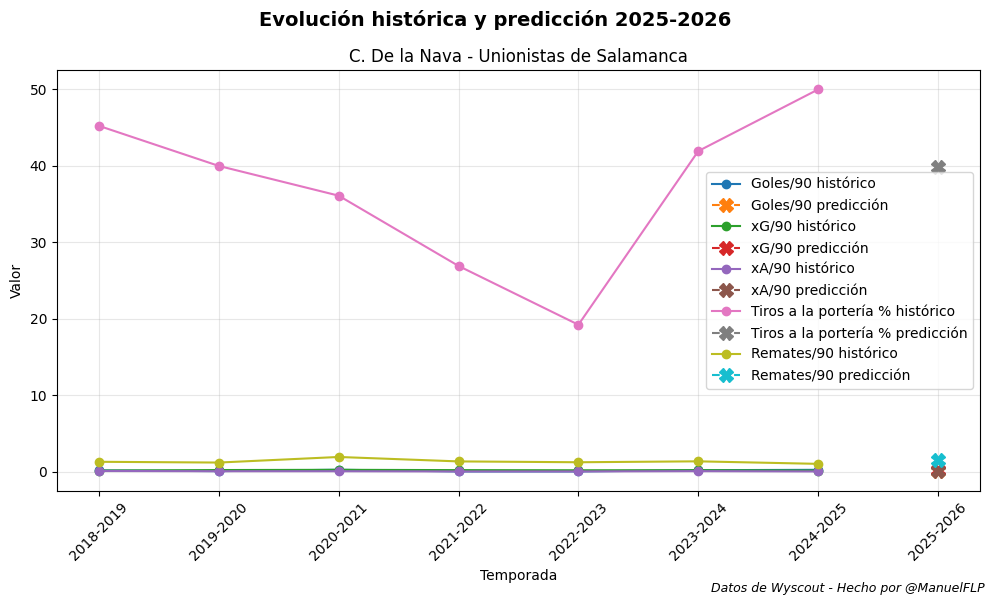

In [35]:
# df_final es el DataFrame ya creado con tus temporadas + la predicción 25-26

# Definimos temporadas históricas y la predicción
historico = df_final[df_final["Temporada"] != temp_pred]
prediccion = df_final[df_final["Temporada"] == temp_pred]

plt.figure(figsize=(10,6))

# Dibujar líneas históricas SELECCIONAR QUE METRICAS QUEREMOS
for col in ["Goles/90","xG/90", "xA/90", "Tiros a la portería %", "Remates/90"]:
    plt.plot(historico["Temporada"], historico[col], marker="o", label=f"{col} histórico")
    plt.plot(prediccion["Temporada"], prediccion[col], marker="X", markersize=10, linestyle="--", label=f"{col} predicción")

# Estética
plt.suptitle("Evolución histórica y predicción " + temp_pred, fontsize=14, fontweight="bold")
plt.title(nombre_jugador + " - " + equipo_jugador, loc="center")
plt.xlabel("Temporada")
plt.ylabel("Valor")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)

# Créditos (como en tus otros gráficos)
plt.figtext(0.99, 0.01, "Datos de Wyscout - Hecho por @ManuelFLP",
            ha="right", fontsize=9, style="italic")

plt.tight_layout()
plt.show()


## **PREDICCIÓN: con subgráficos por métrica**

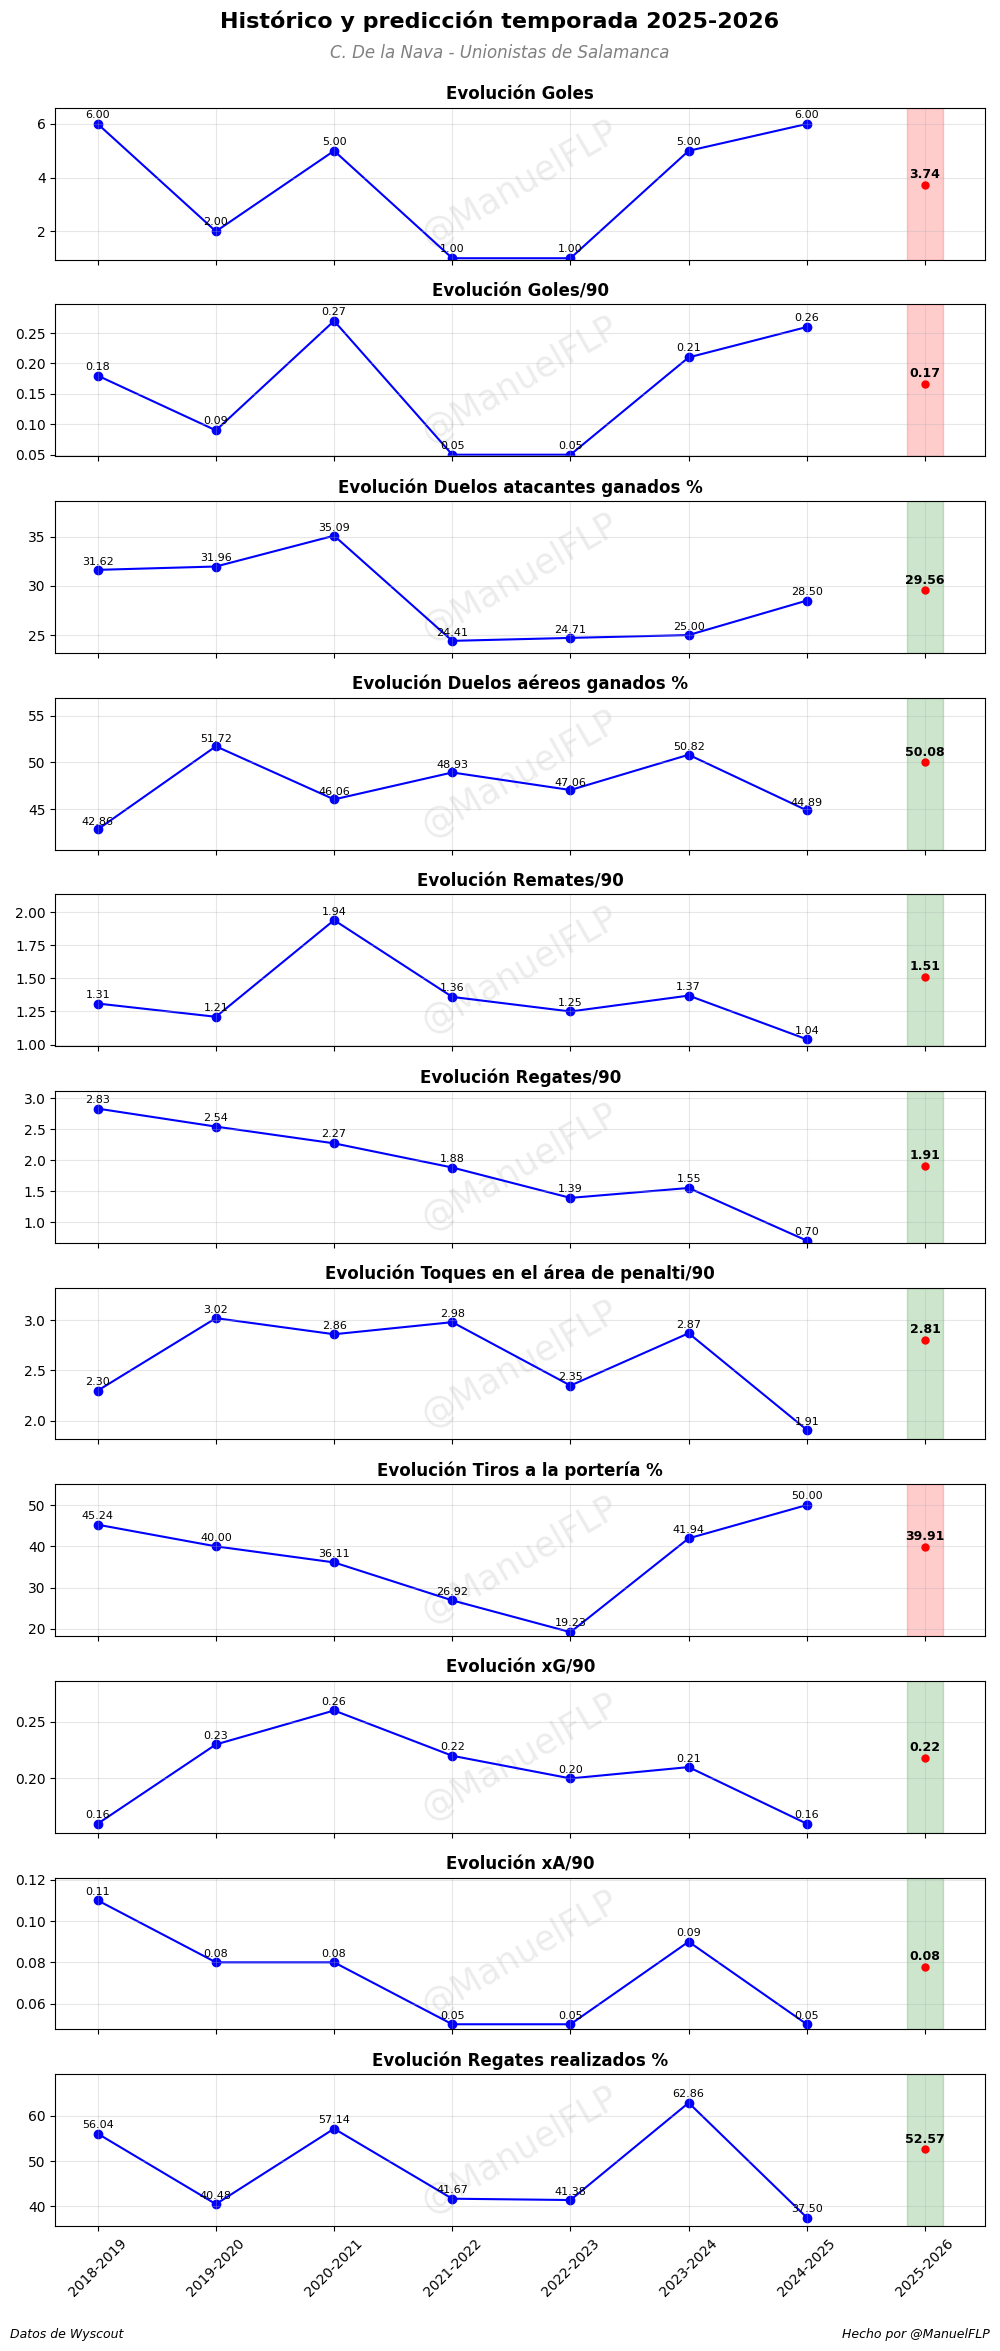

In [24]:
# df_final es tu DataFrame con temporadas históricas + 2025-26 predicha
historico = df_final[df_final["Temporada"] != temp_pred]
prediccion = df_final[df_final["Temporada"] == temp_pred]

#metrica = ["Goles/90","xG/90", "xA/90", "Tiros a la portería %", "Remates/90"]

fig, axes = plt.subplots(len(metrica), 1, figsize=(10, 24), sharex=True)

# Título y subtítulo generales
fig.suptitle("Histórico y predicción temporada " + temp_pred, fontsize=16, fontweight="bold", y=0.96)
fig.text(0.5, 0.940, nombre_jugador + " - " + equipo_jugador, ha="center", fontsize=12, style="italic", color="gray")

# Posiciones X para histórico y predicción
x_vals = np.arange(len(df_final))
historico_x = x_vals[:-1]
pred_x = x_vals[-1]

for i, col in enumerate(metrica):
    ax = axes[i]

    # Marca de agua en cada subplot
    ax.text(0.5, 0.5, "@ManuelFLP", transform=ax.transAxes,
            fontsize=25, color='gray', alpha=0.15,
            ha='center', va='center', rotation=30, zorder=0)

    # Línea histórica
    ax.plot(historico_x, historico[col], marker="o", color="blue", label=f"{col} histórico", zorder=1)

    # Valores históricos
    y_range = historico[col].max() - historico[col].min()
    offset = 0.03 * (y_range if y_range > 0 else 1)   # offset dinámico según rango
    for x, y in zip(historico_x, historico[col]):
        ax.text(x, y + offset, f"{y:.2f}", ha="center", va="bottom", fontsize=8, color="black")

    # Valor predicción
    y_pred = prediccion[col].values[0]
    last_real = historico[col].iloc[-1]

    # Color dinámico de la zona predicción
    zona_color = "green" if y_pred > last_real else "red"
    ax.axvspan(pred_x-0.15, pred_x+0.15, color=zona_color, alpha=0.2, zorder=0)

    # Punto predicción
    y_pred = prediccion[col].values[0]
    ax.plot(pred_x, prediccion[col].values[0], marker="o", markersize=5, linestyle="--", color="red",
            label=f"{col} predicción", zorder=2)

    # Valor de predicción
    ax.text(pred_x, y_pred + offset, f"{y_pred:.2f}",
            ha="center", va="bottom", fontsize=9, color="black", fontweight="bold")


    # Ajustes
    ax.set_title(f"{col}", fontsize=11, fontweight="bold")
    ax.grid(alpha=0.3)

    # --- Ajuste del eje Y ---
    y_max = max(historico[col].max(), y_pred)     # máximo entre histórico y predicción
    y_min = min(historico[col].min(), y_pred)     # mínimo entre histórico y predicción
    ax.set_ylim(y_min - 0.05*abs(y_min), y_max * 1.1)  # margen arriba y abajo

    ax.set_title(f"Evolución {col}", fontsize=12, fontweight="bold")
    #ax.set_xlabel("Temporada")
    #ax.set_ylabel("Valor")
    ax.grid(alpha=0.3)
    #ax.legend(loc="center left", fontsize=9)

# Eje X con nombres de temporadas
plt.xticks(x_vals, df_final["Temporada"], rotation=45)
#plt.xlabel("Temporada")

# Créditos: izquierda y derecha
plt.figtext(0.01, -0.01, "Datos de Wyscout", ha="left", fontsize=9, style="italic")
plt.figtext(0.99, -0.01, "Hecho por @ManuelFLP", ha="right", fontsize=9, style="italic")

# Ajustamos rect para dar más espacio al titulo y subtitulo
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig('Pred_Jugador', dpi=200 )

plt.show()
